# Molt detection data exploration

Loads the pickles produced by `get_molt_detection_data.py` and provides small helpers to inspect the per-timepoint features and their Gaussian keymaps.

- `X[i]`: `(n_features, length)` array of feature channels (e.g. log volume, log-volume growth rate). A 1-D array is treated as a single feature.
- `y[i]`: `(4, length)` Gaussian keymap, one row per molt (M1–M4)
- `keypoints[i]`: the 4 molt frame indices (M1–M4), NaN if missing

The plotting helpers work with **any number of feature channels** — just keep `FEATURE_NAMES` in sync with the features built in the script (extra/missing names fall back to `feature {i}`).

In [11]:
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path(".")
KEYMAP_TYPE = "gaussian"
MOLT_NAMES = ["M1", "M2", "M3", "M4"]

# Names of the feature channels, in the order they are stacked in the script.
# Keep in sync with get_features_and_ground_truth_molts; unnamed channels
# fall back to "feature {i}".
FEATURE_NAMES = ["log volume", "log-volume growth rate"]

X = pickle.load(open(DATA_DIR / "X_molt_detection.pickle", "rb"))
y = pickle.load(open(DATA_DIR / f"y_{KEYMAP_TYPE}_molt_detection.pickle", "rb"))
keypoints = pickle.load(open(DATA_DIR / "keypoints_molt_detection.pickle", "rb"))


def as_features(x):
    """Return sample features as a 2-D (n_features, length) array."""
    x = np.asarray(x)
    return x[None, :] if x.ndim == 1 else x


def feature_labels(n_features):
    return [
        FEATURE_NAMES[i] if i < len(FEATURE_NAMES) else f"feature {i}"
        for i in range(n_features)
    ]


n_features = as_features(X[0]).shape[0]
print(f"{len(X)} samples, {n_features} feature channel(s): {feature_labels(n_features)}")

10674 samples, 2 feature channel(s): ['log volume', 'log-volume growth rate']


In [16]:
print(keypoints)

[[ 72. 117. 159. 219.]
 [ 82. 132. 173. 231.]
 [ 70. 117. 159. 221.]
 ...
 [ 96. 149. 189. 250.]
 [ 79. 129. 171. 229.]
 [ 78. 126. 167. 227.]]


## Dataset overview

series length: min=210 max=995 mean=609 median=573
annotated molts per sample: [  99  347  483  983 8762]


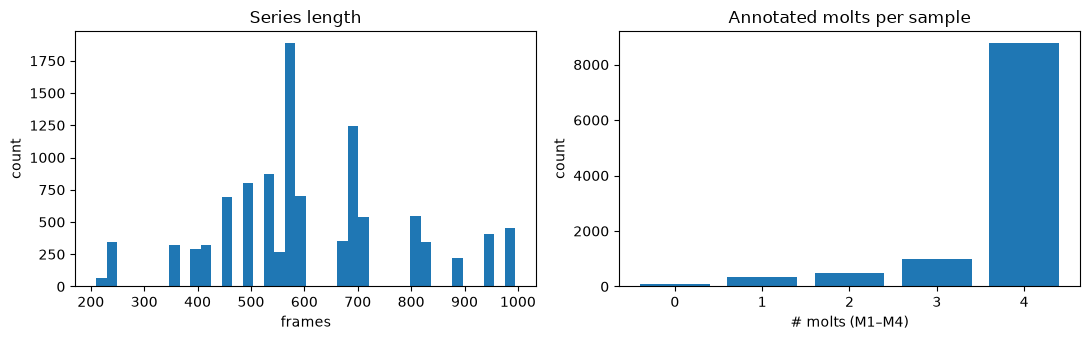

In [12]:
lengths = np.array([as_features(x).shape[-1] for x in X])
n_valid_molts = np.sum(~np.isnan(keypoints), axis=1)

print(f"series length: min={lengths.min()} max={lengths.max()} "
      f"mean={lengths.mean():.0f} median={np.median(lengths):.0f}")
print(f"annotated molts per sample: {np.bincount(n_valid_molts)}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(lengths, bins=40)
axes[0].set(title="Series length", xlabel="frames", ylabel="count")
axes[1].hist(n_valid_molts, bins=np.arange(6) - 0.5, rwidth=0.8)
axes[1].set(title="Annotated molts per sample", xlabel="# molts (M1–M4)", ylabel="count")
axes[1].set_xticks(range(5))
plt.tight_layout()

## Inspect a single sample

One panel per feature channel (with molt frames marked), then the 4 keymap peak curves, then the raw `(4, length)` keymap as a heatmap. Scales to any number of features.

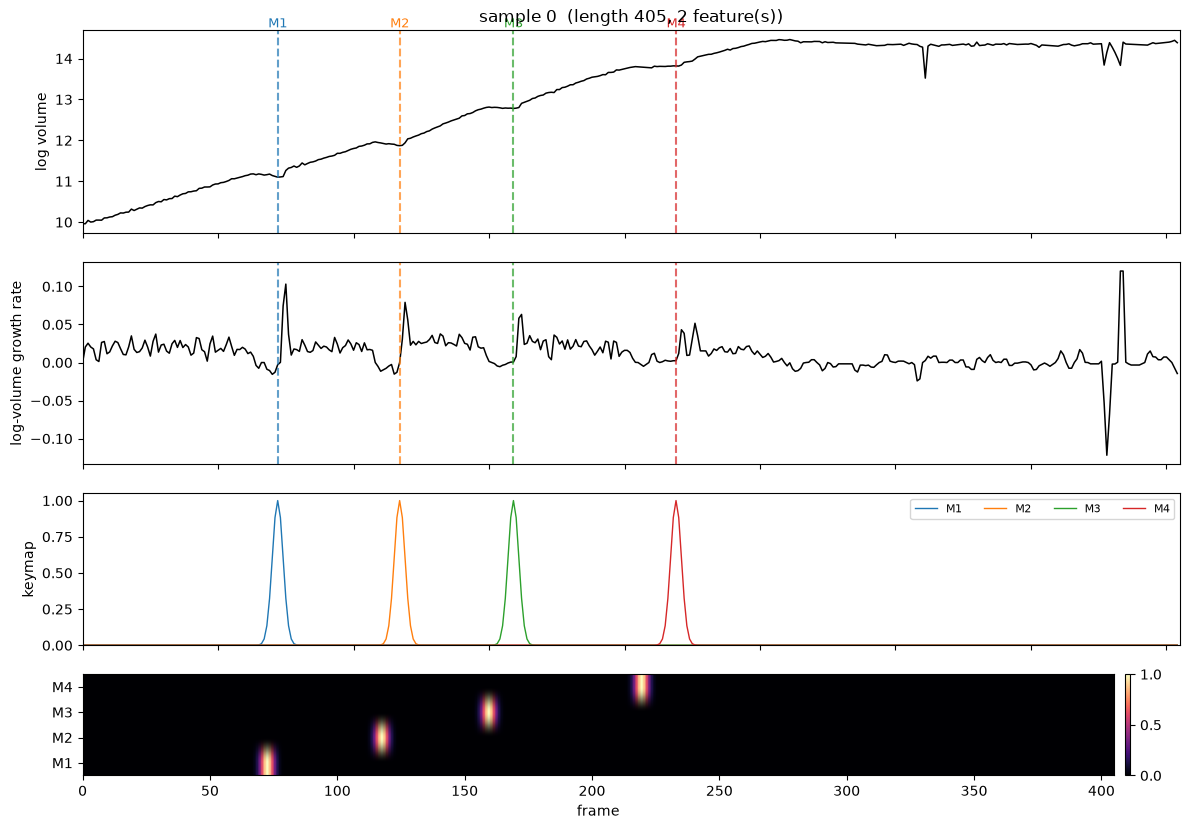

In [13]:
def plot_sample(i):
    feats = as_features(X[i])
    keymap = y[i]
    kp = keypoints[i]
    n_feat, length = feats.shape
    t = np.arange(length)
    labels = feature_labels(n_feat)
    molt_colors = plt.cm.tab10(np.arange(len(MOLT_NAMES)))

    nrows = n_feat + 2  # feature panels + keymap curves + keymap heatmap
    fig, axes = plt.subplots(
        nrows, 1, figsize=(12, 2.1 * nrows), sharex=True,
        gridspec_kw={"height_ratios": [2] * n_feat + [1.5, 1]},
    )

    for ax, series, label in zip(axes, feats, labels):
        ax.plot(t, series, color="black", lw=1.1)
        ax.set_ylabel(label)
        for frame, color in zip(kp, molt_colors):
            if not np.isnan(frame):
                ax.axvline(frame, color=color, ls="--", alpha=0.7)
    axes[0].set_title(f"sample {i}  (length {length}, {n_feat} feature(s))")
    for frame, name, color in zip(kp, MOLT_NAMES, molt_colors):
        if not np.isnan(frame):
            axes[0].text(frame, axes[0].get_ylim()[1], name,
                         color=color, ha="center", va="bottom", fontsize=9)

    ax_curve = axes[n_feat]
    for row, name, color in zip(keymap, MOLT_NAMES, molt_colors):
        ax_curve.plot(t, row, color=color, lw=1, label=name)
    ax_curve.set(ylabel="keymap", ylim=(0, 1.05))
    ax_curve.legend(ncol=len(MOLT_NAMES), fontsize=8, loc="upper right")

    ax_map = axes[n_feat + 1]
    im = ax_map.imshow(keymap, aspect="auto", origin="lower",
                       extent=[0, length, -0.5, len(MOLT_NAMES) - 0.5],
                       cmap="magma", vmin=0, vmax=1)
    ax_map.set(yticks=range(len(MOLT_NAMES)), yticklabels=MOLT_NAMES, xlabel="frame")
    fig.colorbar(im, ax=ax_map, pad=0.01, fraction=0.05)
    plt.tight_layout()


plot_sample(0)

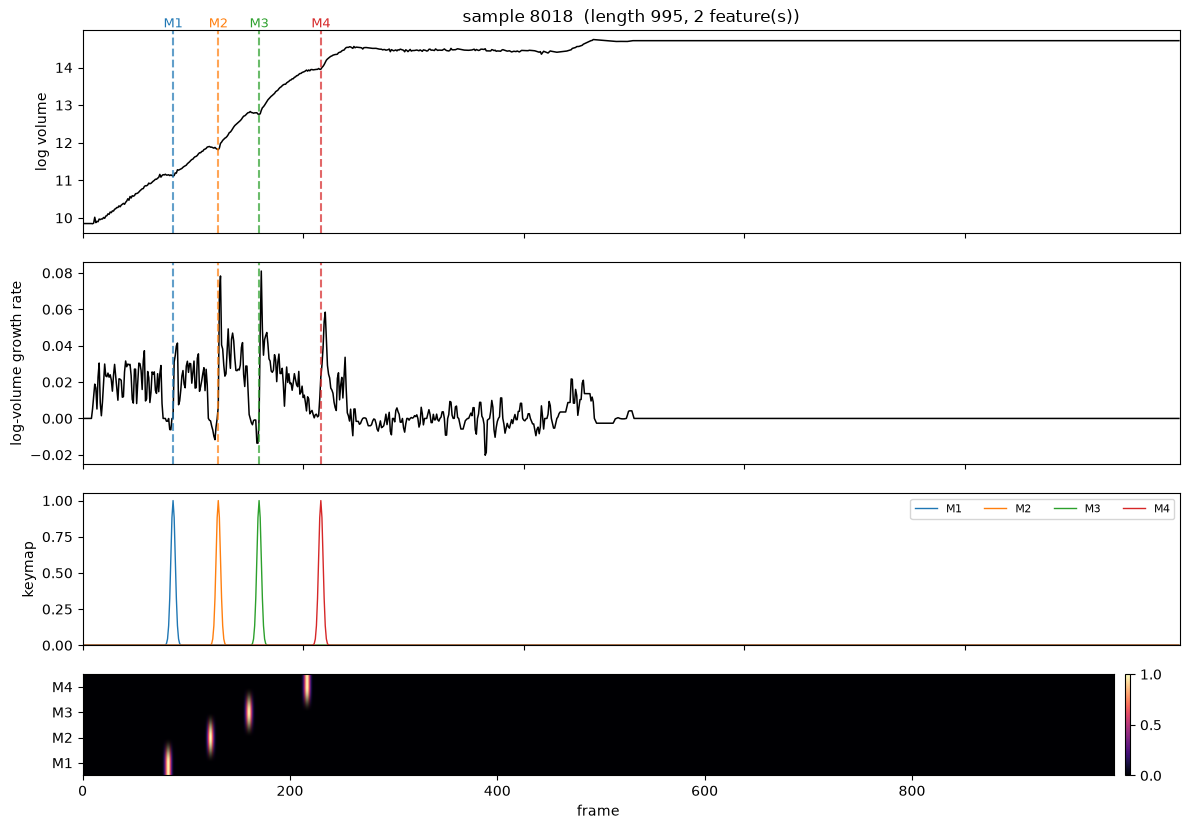

In [14]:
# Look at a random sample (re-run to resample)
plot_sample(np.random.randint(len(X)))

## Grid of samples

Quick scan of many samples for a single feature channel (`feature=` selects which one).

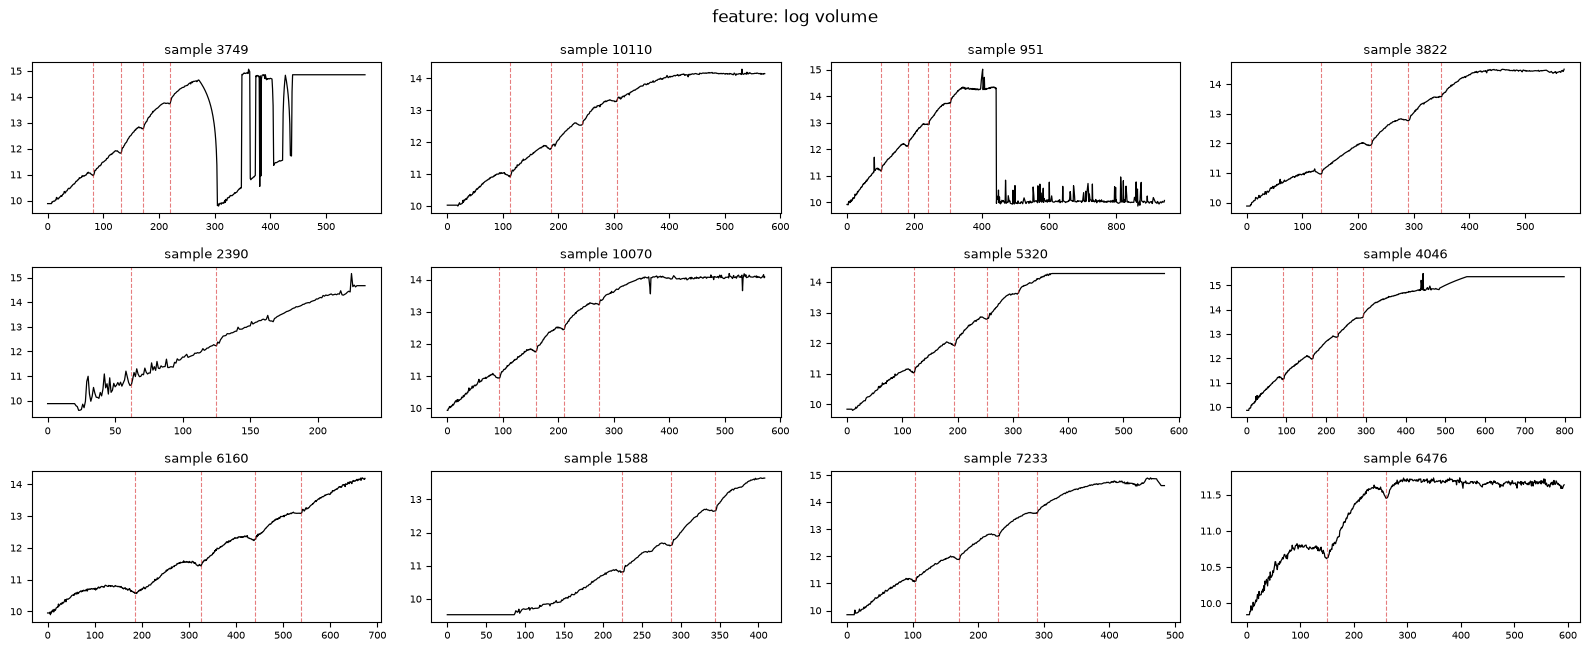

In [15]:
def plot_grid(indices, feature=0, ncols=4):
    indices = list(indices)
    nrows = int(np.ceil(len(indices) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.2 * nrows))
    label = feature_labels(as_features(X[indices[0]]).shape[0])[feature]
    for ax, i in zip(np.ravel(axes), indices):
        ax.plot(as_features(X[i])[feature], color="black", lw=0.9)
        for frame in keypoints[i]:
            if not np.isnan(frame):
                ax.axvline(frame, color="tab:red", ls="--", alpha=0.6, lw=0.8)
        ax.set_title(f"sample {i}", fontsize=9)
        ax.tick_params(labelsize=7)
    for ax in np.ravel(axes)[len(indices):]:
        ax.axis("off")
    fig.suptitle(f"feature: {label}")
    plt.tight_layout()


plot_grid(np.random.choice(len(X), size=12, replace=False), feature=0)